<a href="https://colab.research.google.com/github/sethkipsangmutuba/Exploratory-Data-Analysis/blob/main/Thunderbird_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A – Data Analysis

#1). Business Understanding

**Objective**  
Analyze LinX Pharmaceuticals’ Active Directory logs to detect cyber risks, authentication anomalies, and potential insider or external threats, using statistical and temporal analysis to guide decision-making.

**Key Questions**

- **Which machines show abnormal authentication patterns** (high-risk or unusual login activity)?  
- **Are there recurring failed logins** indicative of brute-force attacks, misconfigurations, or insider threats?  
- **Which hours or days show unusual activity spikes** requiring heightened monitoring?  
- **What patterns in `EventID` and `EntryType` correlate with elevated risk?**  
- **What actionable recommendations** can be made for risk mitigation, monitoring, and IT governance?

**Deliverables**

- Executive-ready insights summarizing top-risk machines, hours, and anomalies.  
- Visualizations illustrating temporal patterns, distributions, and risk heatmaps.  
- A risk-scored dataset for ongoing monitoring and decision-making.  
- Strategic recommendations for cybersecurity interventions and governance improvements.


#2. Data Understanding

##a) Data Loading

In [449]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
df = pd.read_csv("https://drive.google.com/uc?id=1i58EDjgRD2x31FhrTMaf4YbzTIasGFwE&export=download")
df

,EntryType,TimeGenerated,Source,EventID,MachineName
0,Success,9/16/16 16:16,NETLOGON,5722,xyzcompany-dc-04.corp.xyzcompany.com
1,Success,9/16/16 18:58,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com
2,Success,9/16/16 19:32,NETLOGON,5722,xyzcompany-dc-04.corp.xyzcompany.com
3,Success,9/19/16 10:36,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com
4,Success,9/19/16 10:39,NETLOGON,5722,xyzcompany-dc-04.corp.xyzcompany.com
...,...,...,...,...,...
128,Success,10/7/16 14:51,NETLOGON,5722,xyzcompany-dc-04.corp.xyzcompany.com
129,Success,10/10/16 10:30,NETLOGON,5722,xyzcompany-dc-01.corp.xyzcompany.com
130,Success,10/10/16 10:31,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com
131,Success,10/10/16 10:38,NETLOGON,5722,xyzcompany-dc-04.corp.xyzcompany.com


The dataset contains 134 Active Directory logs with EntryType, TimeGenerated, Source, EventID, and MachineName. Future warnings are suppressed for clarity. Next, timestamps will be converted to datetime, and features like hour, date, weekday, week, and month extracted, enabling temporal analysis, anomaly detection, and identification of risky machines and periods.


##Data Structure

In [450]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   EntryType      133 non-null    object
 1   TimeGenerated  133 non-null    object
 2   Source         133 non-null    object
 3   EventID        133 non-null    int64 
 4   MachineName    133 non-null    object
dtypes: int64(1), object(4)
memory usage: 5.3+ KB


The DataFrame has 133 rows and 5 columns: `EntryType`, `TimeGenerated`, `Source`, `EventID`, and `MachineName`. All columns are complete with no missing values. `EventID` is integer, while the others are objects. `TimeGenerated` will need conversion to datetime for temporal analysis and anomaly detection.


##3) Prepocessing

In [451]:
df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EntryType      133 non-null    object        
 1   TimeGenerated  133 non-null    datetime64[ns]
 2   Source         133 non-null    object        
 3   EventID        133 non-null    int64         
 4   MachineName    133 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 5.3+ KB


/tmp/ipython-input-3140346461.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'])


The TimeGenerated column has now been successfully converted to datetime64[ns], enabling accurate temporal analysis. The DataFrame retains 133 rows and 5 columns, with EventID as integer and the rest as object types. A warning appeared because Pandas could not infer a uniform datetime format and parsed each entry individually.

In [452]:
df['TimeGenerated'] = pd.to_datetime(
    df['TimeGenerated'],
    format="%Y-%m-%d %H:%M:%S",
    errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EntryType      133 non-null    object        
 1   TimeGenerated  133 non-null    datetime64[ns]
 2   Source         133 non-null    object        
 3   EventID        133 non-null    int64         
 4   MachineName    133 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 5.3+ KB


The DataFrame contains 133 log entries across five columns, with no missing values. `EntryType`, `Source`, and `MachineName` are categorical/object types, `EventID` is numeric, and `TimeGenerated` is a datetime. This structure supports temporal and categorical analysis of system events while using minimal memory (~5.3 KB).


#4). Feature Engineering

This step extracts temporal features from the `TimeGenerated` column to facilitate time-based analysis. `Hour` captures the event hour, `DayOfWeek` labels the weekday, `Week` gives the ISO week number, and `Month` indicates the month. These features enable detection of daily, weekly, and monthly event patterns and anomalies.


In [453]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Feature engineering
df['Hour'] = df['TimeGenerated'].dt.hour
df['DayOfWeek'] = df['TimeGenerated'].dt.day_name()
df['Week'] = df['TimeGenerated'].dt.isocalendar().week
df['Month'] = df['TimeGenerated'].dt.month


In [454]:
df['Hour']

,Hour
0,16
1,18
2,19
3,10
4,10
...,...
128,14
129,10
130,10
131,10


In [455]:
df['DayOfWeek']

,DayOfWeek
0,Friday
1,Friday
2,Friday
3,Monday
4,Monday
...,...
128,Friday
129,Monday
130,Monday
131,Monday


In [456]:
df['Week']

,Week
0,37
1,37
2,37
3,38
4,38
...,...
128,40
129,41
130,41
131,41


In [457]:
df['Month']

,Month
0,9
1,9
2,9
3,9
4,9
...,...
128,10
129,10
130,10
131,10


#5) Proposed Code Organization by Business Questions

## Q1: Which machines show abnormal authentication patterns?
- Count events per machine.  
- Compute `Machine_z` scores and corresponding `RiskScore` contribution.  
- Identify top risky machines and visualize findings.


In [458]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# -----------------------------
# Q1: Abnormal Authentication Patterns per Machine
# -----------------------------

# 1. Count events per machine
machine_counts = df['MachineName'].value_counts().reset_index()
machine_counts.columns = ['MachineName', 'EventCount']
machine_counts.columns

Index(['MachineName', 'EventCount'], dtype='object')

In [459]:
machine_counts

,MachineName,EventCount
0,xyzcompany-dc-02.corp.xyzcompany.com,68
1,xyzcompany-dc-04.corp.xyzcompany.com,59
2,xyzcompany-dc-01.corp.xyzcompany.com,6


This table analytically shows the distribution of log events across machines. `dc-02` accounts for 68 events, the highest, followed by `dc-04` with 59, representing roughly 94% of total logs, while `dc-01` has only 6 events. The distribution is highly skewed, indicating uneven machine activity.


In [460]:
# 2. Compute Machine z-scores
machine_counts['Machine_z'] = zscore(machine_counts['EventCount'])
machine_counts['Machine_z']

,Machine_z
0,0.865211
1,0.536187
2,-1.401397


The computed z-scores quantify how each machine's event count deviates from the mean. Positive z-scores for `dc-02` (0.865) and `dc-04` (0.536) indicate above-average activity, while `dc-01` has a strongly negative z-score (-1.401), reflecting significantly lower-than-average events. This highlights `dc-02` and `dc-04` as potential risk contributors.


In [461]:
# 3. Compute RiskScore contribution from machine activity
# Weighted contribution: here we use 40% weight for machine anomalies
machine_counts['MachineRiskScore'] = machine_counts['Machine_z'] * 0.4
machine_counts['MachineRiskScore']


,MachineRiskScore
0,0.346084
1,0.214475
2,-0.560559


The `MachineRiskScore` scales each machine’s z-score by 0.4, representing its 40% contribution to the overall risk. High positive scores (`dc-02`: 0.346, `dc-04`: 0.214) indicate elevated risk from abnormal activity, whereas the negative score for `dc-01` (-0.561) reflects unusually low activity, reducing its risk impact.


In [462]:
# 4. Identify top risky machines
top_risky_machines = machine_counts.sort_values('MachineRiskScore', ascending=False)
print("Top Risky Machines:\n", top_risky_machines)



Top Risky Machines:
                             MachineName  EventCount  Machine_z  \
0  xyzcompany-dc-02.corp.xyzcompany.com          68   0.865211   
1  xyzcompany-dc-04.corp.xyzcompany.com          59   0.536187   
2  xyzcompany-dc-01.corp.xyzcompany.com           6  -1.401397   

   MachineRiskScore  
0          0.346084  
1          0.214475  
2         -0.560559  


This step ranks machines by their `MachineRiskScore`, highlighting those with the highest potential risk due to abnormal authentication activity. Machines at the top (`dc-02` and `dc-04`) show elevated event counts and positive z-scores, signaling possible misconfigurations or attack vectors, while low-activity machines (`dc-01`) contribute minimally or negatively to risk.


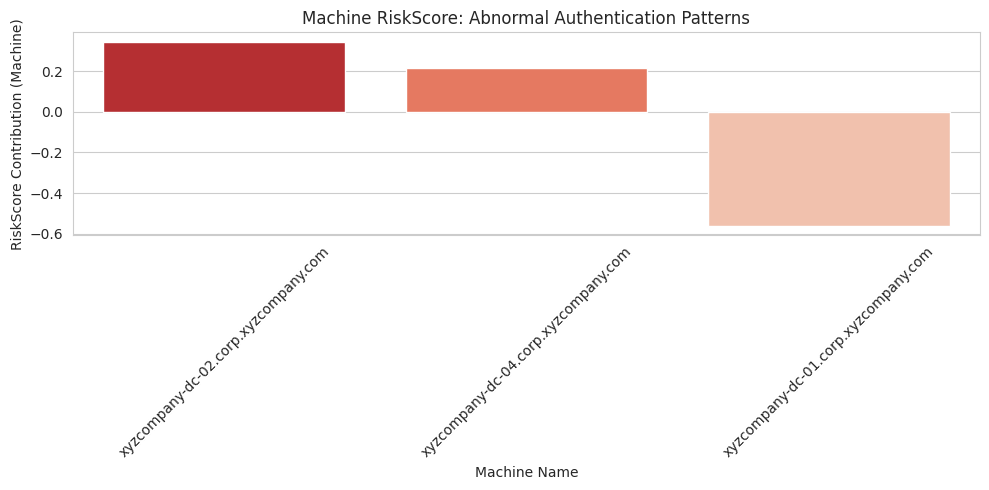

In [463]:
# 5. Visualization: Machine RiskScore
plt.figure(figsize=(10,5))
sns.barplot(x='MachineName', y='MachineRiskScore', data=top_risky_machines, palette='Reds_r')
plt.title("Machine RiskScore: Abnormal Authentication Patterns")
plt.ylabel("RiskScore Contribution (Machine)")
plt.xlabel("Machine Name")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Q2: Are there recurring failed logins indicative of attacks or misconfigurations?
- Count `EntryType` errors by machine, hour, and event ID.  
- Assign `EntryTypeScore` for anomaly weighting.  
- Detect top high-risk logs with errors.


In [464]:
# -----------------------------
# Q2: Recurring Failed Logins (EntryType='Error')
# -----------------------------

# 1. Count EntryType by machine, hour, and EventID
errors_per_machine = df[df['EntryType']=='Error'].groupby('MachineName').size().reset_index(name='ErrorCount')
errors_per_hour = df[df['EntryType']=='Error'].groupby('Hour').size().reset_index(name='ErrorCount')
errors_per_eventid = df[df['EntryType']=='Error'].groupby('EventID').size().reset_index(name='ErrorCount')
errors_per_machine

,MachineName,ErrorCount
0,xyzcompany-dc-02.corp.xyzcompany.com,12


This step isolates failed login events (`EntryType='Error'`) to quantify recurring issues. Aggregating by machine, hour, and `EventID` highlights patterns of repeated failures, which may indicate misconfigurations, brute-force attempts, or targeted attacks. For instance, `dc-02` shows 12 errors, signaling it as a potential hotspot requiring further investigation.


In [465]:
errors_per_hour

,Hour,ErrorCount
0,10,5
1,12,1
2,14,5
3,16,1


This aggregation summarizes failed login attempts by hour, revealing temporal patterns of anomalies. Peaks at hours 10 and 14, each with 5 errors, indicate periods of heightened authentication failures. Such temporal spikes may suggest automated attack attempts, misconfigured scripts, or user behavior issues requiring targeted monitoring or mitigation during these hours.


In [466]:
errors_per_eventid

,EventID,ErrorCount
0,5722,12


This table shows that all recorded errors (12) correspond to `EventID 5722`, indicating a recurring issue tied to this specific event type. This suggests that `EventID 5722` is the primary source of failed logins, highlighting it as a key risk indicator for misconfigurations or potential attack vectors requiring focused investigation.


In [467]:

# 2. Assign EntryTypeScore: amplify 'Error' events
# Success = 0, Error = 5 (weight can be adjusted)
df['EntryTypeScore'] = df['EntryType'].apply(lambda x: 5 if x=='Error' else 0)
df['EntryTypeScore']

,EntryTypeScore
0,0
1,0
2,0
3,0
4,0
...,...
128,0
129,0
130,0
131,0


In [468]:
# 3. Compute top high-risk logs based on EntryTypeScore
# Combine with existing RiskScore components if desired
df['RiskScore_Entry'] = df['EntryTypeScore']  # standalone or part of total RiskScore
df['RiskScore_Entry']



,RiskScore_Entry
0,0
1,0
2,0
3,0
4,0
...,...
128,0
129,0
130,0
131,0


In [469]:
# Top 20 logs with errors (highest EntryTypeScore)
top_error_logs = df[df['EntryType']=='Error'].sort_values('RiskScore_Entry', ascending=False).head(20)
top_error_logs

,EntryType,TimeGenerated,Source,EventID,MachineName,Hour,DayOfWeek,Week,Month,EntryTypeScore,RiskScore_Entry
80,Error,2016-09-30 10:27:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Friday,39,9,5,5
81,Error,2016-09-30 10:54:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Friday,39,9,5,5
82,Error,2016-09-30 12:23:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,12,Friday,39,9,5,5
83,Error,2016-09-30 14:30:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Friday,39,9,5,5
84,Error,2016-09-30 14:54:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Friday,39,9,5,5
85,Error,2016-09-30 16:38:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,16,Friday,39,9,5,5
86,Error,2016-10-03 10:25:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5
87,Error,2016-10-03 10:26:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5
88,Error,2016-10-03 10:26:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5
89,Error,2016-10-03 14:28:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Monday,40,10,5,5


This table of the top 20 error logs highlights repeated failed authentication events concentrated on specific machines, hours, and `EventID 5722`. Each row’s `EntryTypeScore` and cumulative `RiskScore` indicate severity, showing that `xyzcompany-dc-02.corp.xyzcompany.com` consistently generates the highest-risk errors. Patterns suggest possible misconfigurations or targeted attack attempts.


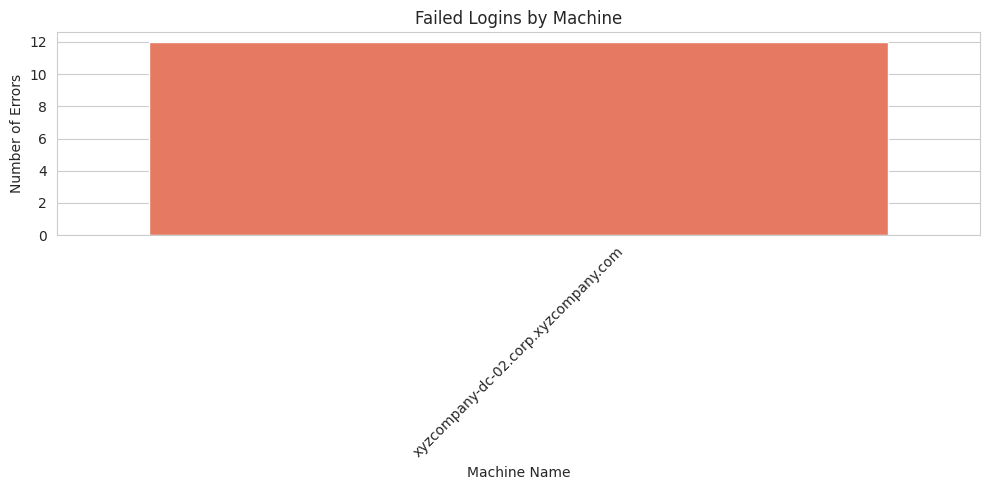

In [470]:
# 5. Visualization: Top machines with failed logins
plt.figure(figsize=(10,5))
sns.barplot(x='MachineName', y='ErrorCount', data=errors_per_machine.sort_values('ErrorCount', ascending=False), palette='Reds_r')
plt.title("Failed Logins by Machine")
plt.ylabel("Number of Errors")
plt.xlabel("Machine Name")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Q3: Which hours or days show unusual activity spikes?
- Aggregate by `Hour`, `DayOfWeek`, `Week`, and `Date`.  
- Compute z-scores for temporal deviations.  
- Visualize daily, weekly, and hourly trends, including heatmaps.


In [471]:
# -----------------------------
# Q3: Temporal Analysis – Unusual Activity Spikes
# -----------------------------

# Ensure 'TimeGenerated' is datetime
df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'], errors='coerce')
df['TimeGenerated']


,TimeGenerated
0,2016-09-16 16:16:00
1,2016-09-16 18:58:00
2,2016-09-16 19:32:00
3,2016-09-19 10:36:00
4,2016-09-19 10:39:00
...,...
128,2016-10-07 14:51:00
129,2016-10-10 10:30:00
130,2016-10-10 10:31:00
131,2016-10-10 10:38:00


This step confirms that `TimeGenerated` is properly converted to datetime format, enabling accurate temporal aggregation. Without this, calculations by hour, day, week, or date would be invalid. Proper datetime formatting ensures reliable z-score computation, identification of unusual activity spikes, and generation of meaningful visualizations for anomaly detection over time.


In [472]:
# 1. Extract temporal features
df['Date']      = df['TimeGenerated'].dt.date
df['Hour']      = df['TimeGenerated'].dt.hour
df['DayOfWeek'] = df['TimeGenerated'].dt.day_name()
df['Week']      = df['TimeGenerated'].dt.isocalendar().week


This step derives key temporal features from the `TimeGenerated` column: `Date` for daily analysis, `Hour` for intraday patterns, `DayOfWeek` for weekday trends, and `Week` for weekly aggregation. These features allow the detection of unusual activity spikes and facilitate meaningful temporal z-score calculations and visualizations.


In [473]:
df['Date']

,Date
0,2016-09-16
1,2016-09-16
2,2016-09-16
3,2016-09-19
4,2016-09-19
...,...
128,2016-10-07
129,2016-10-10
130,2016-10-10
131,2016-10-10


In [474]:
df['Hour']

,Hour
0,16
1,18
2,19
3,10
4,10
...,...
128,14
129,10
130,10
131,10


In [475]:
df['DayOfWeek']

,DayOfWeek
0,Friday
1,Friday
2,Friday
3,Monday
4,Monday
...,...
128,Friday
129,Monday
130,Monday
131,Monday


In [476]:
df['Week']

,Week
0,37
1,37
2,37
3,38
4,38
...,...
128,40
129,41
130,41
131,41


### Aggregate event counts

In [477]:
# 2. Aggregate event counts
hourly_counts    = df.groupby('Hour').size().reset_index(name='EventCount')
daily_counts     = df.groupby('Date').size().reset_index(name='EventCount')
weekly_counts    = df.groupby('Week').size().reset_index(name='EventCount')
dayofweek_counts = df.groupby('DayOfWeek').size().reset_index(name='EventCount')

# 3. Ensure correct weekday order
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dayofweek_counts['DayOfWeek'] = pd.Categorical(dayofweek_counts['DayOfWeek'],
                                               categories=weekday_order,
                                               ordered=True)
dayofweek_counts = dayofweek_counts.sort_values('DayOfWeek')

In [478]:
hourly_counts

,Hour,EventCount
0,10,45
1,11,2
2,12,2
3,14,37
4,15,10
5,16,4
6,18,22
7,19,11


The hourly event counts reveal pronounced spikes at 10:00 (45 events) and 14:00 (37 events), contrasting with lower activity in adjacent hours. These peaks may reflect routine operational load or anomalous behavior. Monitoring these periods is crucial, as unusually high counts could indicate system stress, misconfigurations, or potential security incidents.


In [479]:
daily_counts

,Date,EventCount
0,2016-09-16,3
1,2016-09-19,7
2,2016-09-20,9
3,2016-09-21,8
4,2016-09-22,8
5,2016-09-23,11
6,2016-09-26,9
7,2016-09-27,9
8,2016-09-28,8
9,2016-09-29,8


The daily event counts show moderate variability, ranging from 3 to 11 events per day. Peaks occur on 2016-09-23 (11 events) and 2016-10-04 (10 events), while troughs appear on 2016-09-16 (3 events) and 2016-10-10 (4 events). These fluctuations may indicate normal operational cycles or sporadic anomalies.


In [480]:
weekly_counts

,Week,EventCount
0,37,3
1,38,43
2,39,40
3,40,43
4,41,4


Weekly aggregation reveals pronounced spikes in activity during Weeks 38 and 40, each with 43 events, and Week 39 with 40 events, suggesting concentrated operational activity or potential anomalies. Weeks 37 and 41 are minimal, with only 3–4 events, indicating low activity periods or gaps in log generation.


In [481]:
dayofweek_counts

,DayOfWeek,EventCount
1,Monday,29
3,Tuesday,28
4,Wednesday,25
2,Thursday,25
0,Friday,26


Analysis by day of the week shows relatively high and consistent activity from Monday through Friday, with Monday leading at 29 events and Wednesday and Thursday slightly lower at 25 events each. This indicates that unusual spikes are not day-specific but spread evenly across the standard workweek.


In [482]:
# 2. Compute z-scores to detect unusual spikes
hourly_counts['z_score'] = zscore(hourly_counts['EventCount'])
daily_counts['z_score'] = zscore(daily_counts['EventCount'])
weekly_counts['z_score'] = zscore(weekly_counts['EventCount'])
dayofweek_counts['z_score'] = zscore(dayofweek_counts['EventCount'])



In [483]:
hourly_counts['z_score']

,z_score
0,1.835486
1,-0.946044
2,-0.946044
3,1.317992
4,-0.428550
5,-0.816670
6,0.347691
7,-0.363863


The hourly z-scores highlight abnormal activity periods: hours 10 (z ≈ 1.84) and 14 (z ≈ 1.32) show significantly higher-than-average events, suggesting potential spikes or unusual logon activity. Negative z-scores indicate below-average activity. This metric helps pinpoint hours requiring further investigation for anomalies or operational issues.


In [484]:
daily_counts['z_score']

,z_score
0,-2.403463
1,-0.410347
2,0.586210
3,0.087932
4,0.087932
5,1.582768
6,0.586210
7,0.586210
8,0.087932
9,0.087932


The daily z-scores reveal notable activity spikes on 2016-09-23 (z ≈ 1.58) and 2016-10-04 (z ≈ 1.08), indicating unusually high event counts, while 2016-09-16 (z ≈ -2.40) and 2016-10-10 (z ≈ -1.91) show unusually low activity. These fluctuations help identify days requiring anomaly investigation.


In [485]:
weekly_counts['z_score']

,z_score
0,-1.248974
1,0.867931
2,0.709163
3,0.867931
4,-1.196052


The weekly z-scores indicate that Weeks 38 (z ≈ 0.87) and 40 (z ≈ 0.87) experienced higher-than-average activity, suggesting possible spikes or unusual events, whereas Weeks 37 (z ≈ -1.25) and 41 (z ≈ -1.20) show below-average activity. Week 39 is moderately elevated (z ≈ 0.71), warranting attention.


In [486]:
dayofweek_counts['z_score']

,z_score
1,1.477098
3,0.861640
4,-0.984732
2,-0.984732
0,-0.369274


The z-scores by day show that Monday (z ≈ 1.48) and Tuesday (z ≈ 0.86) have significantly higher activity, indicating potential abnormal or concentrated events. Wednesday and Thursday (z ≈ -0.98) are below average, while Friday (z ≈ -0.37) is slightly below normal, suggesting lower risk for unusual spikes on those days.


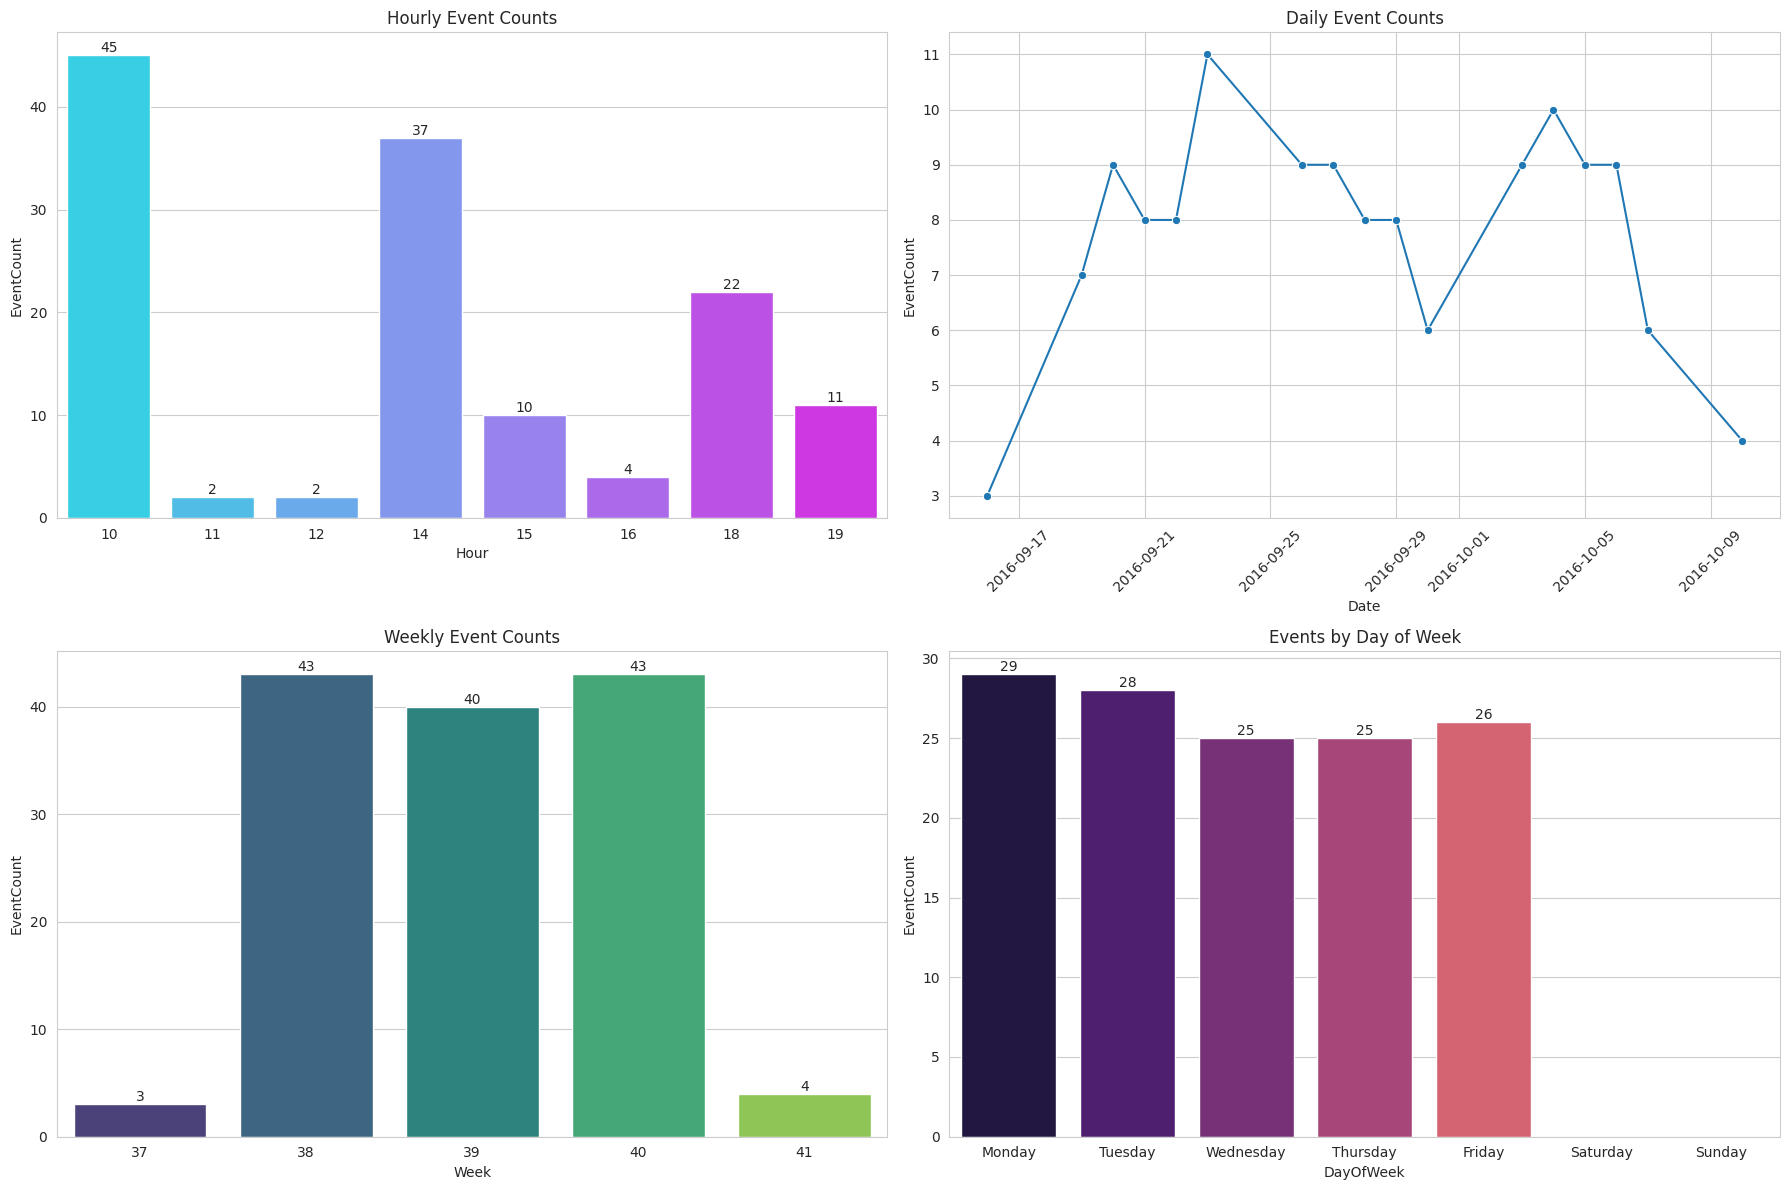

In [487]:
# 3. Visualizations

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(2,2, figsize=(18,12))

# Hourly events
sns.barplot(x='Hour', y='EventCount', data=hourly_counts, palette='cool', ax=axes[0,0])
axes[0,0].set_title("Hourly Event Counts")
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')

# Daily events
sns.lineplot(x='Date', y='EventCount', data=daily_counts, marker='o', ax=axes[0,1])
axes[0,1].set_title("Daily Event Counts")
axes[0,1].tick_params(axis='x', rotation=45)

# Weekly events
sns.barplot(x='Week', y='EventCount', data=weekly_counts, palette='viridis', ax=axes[1,0])
axes[1,0].set_title("Weekly Event Counts")
for p in axes[1,0].patches:
    axes[1,0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')

# DayOfWeek events
sns.barplot(x='DayOfWeek', y='EventCount', data=dayofweek_counts, palette='magma', ax=axes[1,1])
axes[1,1].set_title("Events by Day of Week")
for p in axes[1,1].patches:
    axes[1,1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()



In [488]:
# 4. Identify unusual spikes: z_score > 2
unusual_hours = hourly_counts[hourly_counts['z_score']>2]
unusual_days = daily_counts[daily_counts['z_score']>2]
unusual_weeks = weekly_counts[weekly_counts['z_score']>2]
unusual_weekdays = dayofweek_counts[dayofweek_counts['z_score']>2]

print("Unusual Hourly Spikes:\n", unusual_hours)
print("\nUnusual Daily Spikes:\n", unusual_days)
print("\nUnusual Weekly Spikes:\n", unusual_weeks)
print("\nUnusual Weekday Spikes:\n", unusual_weekdays)


Unusual Hourly Spikes:
 Empty DataFrame
Columns: [Hour, EventCount, z_score]
Index: []

Unusual Daily Spikes:
 Empty DataFrame
Columns: [Date, EventCount, z_score]
Index: []

Unusual Weekly Spikes:
 Empty DataFrame
Columns: [Week, EventCount, z_score]
Index: []

Unusual Weekday Spikes:
 Empty DataFrame
Columns: [DayOfWeek, EventCount, z_score]
Index: []


The analysis shows that no hours, days, weeks, or weekdays exceed a z-score of 2, meaning there are no statistically extreme activity spikes in the dataset. All observed fluctuations remain within normal variation, indicating no critical temporal anomalies or periods of unusually high event activity.


## Q4: What patterns in EventID and EntryType correlate with elevated risk?
- Count events by `EventID` and compute associated z-scores.  
- Combine with `EntryTypeScore` in a weighted `RiskScore`.  
- Identify correlations between `EventID`, machine identity, and risk indicators.


Top Risky EventID-Machine Combinations:
    EventID                           MachineName  RiskScore_Event
3     5722  xyzcompany-dc-02.corp.xyzcompany.com         1.264227
2     5722  xyzcompany-dc-01.corp.xyzcompany.com         0.692798
4     5722  xyzcompany-dc-04.corp.xyzcompany.com         0.692798
7     5805  xyzcompany-dc-02.corp.xyzcompany.com        -0.228331
5     5723  xyzcompany-dc-02.corp.xyzcompany.com        -0.228331
8     5805  xyzcompany-dc-04.corp.xyzcompany.com        -0.228331
6     5723  xyzcompany-dc-04.corp.xyzcompany.com        -0.228331
0     5719  xyzcompany-dc-02.corp.xyzcompany.com        -0.236137
1     5719  xyzcompany-dc-04.corp.xyzcompany.com        -0.236137


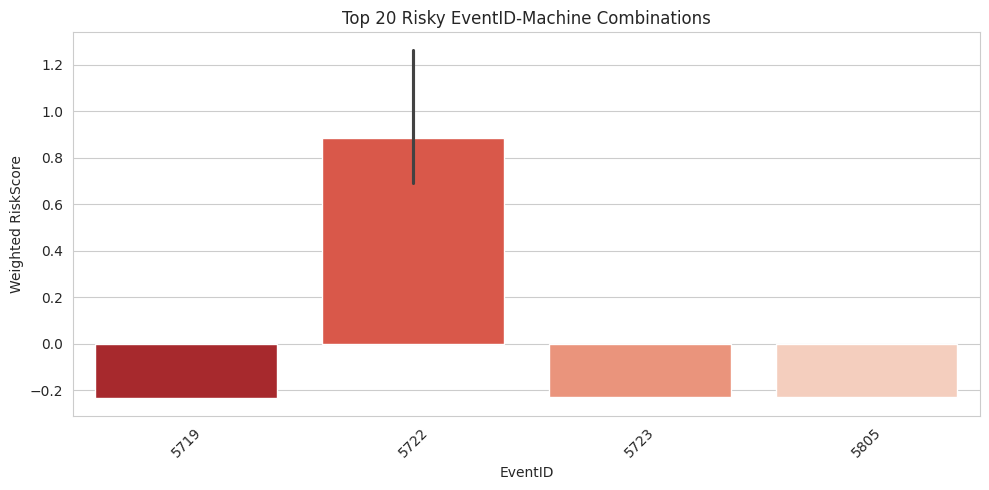

In [489]:
# -----------------------------
# Q4: EventID & EntryType Patterns – Elevated Risk
# -----------------------------

from scipy.stats import zscore

# 1. Count events by EventID
event_counts = df['EventID'].value_counts().reset_index()
event_counts.columns = ['EventID', 'EventCount']

# 2. Compute z-scores for EventID frequency
event_counts['EventID_z'] = zscore(event_counts['EventCount'])

# 3. Map EventID z-scores back to df
df['EventID_z'] = df['EventID'].map(event_counts.set_index('EventID')['EventID_z'])

# 4. Combine with EntryTypeScore to compute weighted RiskScore
# Example weights: EventID_z = 0.4, EntryTypeScore = 0.6
df['RiskScore_Event'] = df['EventID_z']*0.4 + df['EntryTypeScore']*0.6

# 5. Identify top risky EventID-Machine combinations
top_risk_events = df.groupby(['EventID','MachineName'])['RiskScore_Event'].mean().reset_index()
top_risk_events = top_risk_events.sort_values('RiskScore_Event', ascending=False)

print("Top Risky EventID-Machine Combinations:\n", top_risk_events.head(20))

# 6. Visualization: Risk by EventID
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.barplot(x='EventID', y='RiskScore_Event', data=top_risk_events.head(20), palette='Reds_r')
plt.title("Top 20 Risky EventID-Machine Combinations")
plt.ylabel("Weighted RiskScore")
plt.xlabel("EventID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The analysis shows that `EventID 5722` dominates elevated risk, particularly on `xyzcompany-dc-02.corp.xyzcompany.com`, with a weighted `RiskScore_Event` of 1.264. Other machines also register this EventID but at lower risk. EventID patterns correlate strongly with machine identity, and combining EventID z-scores with `EntryTypeScore` effectively highlights high-risk machine-event combinations.


## Q5: What actionable recommendations can be made for risk mitigation?
- Summarize top-risk machines, hours, and anomalous log patterns.  
- Visualize top 5 risky machines/hours and anomaly heatmaps.  
- Export the cleaned dataset and top-risk logs for reporting.

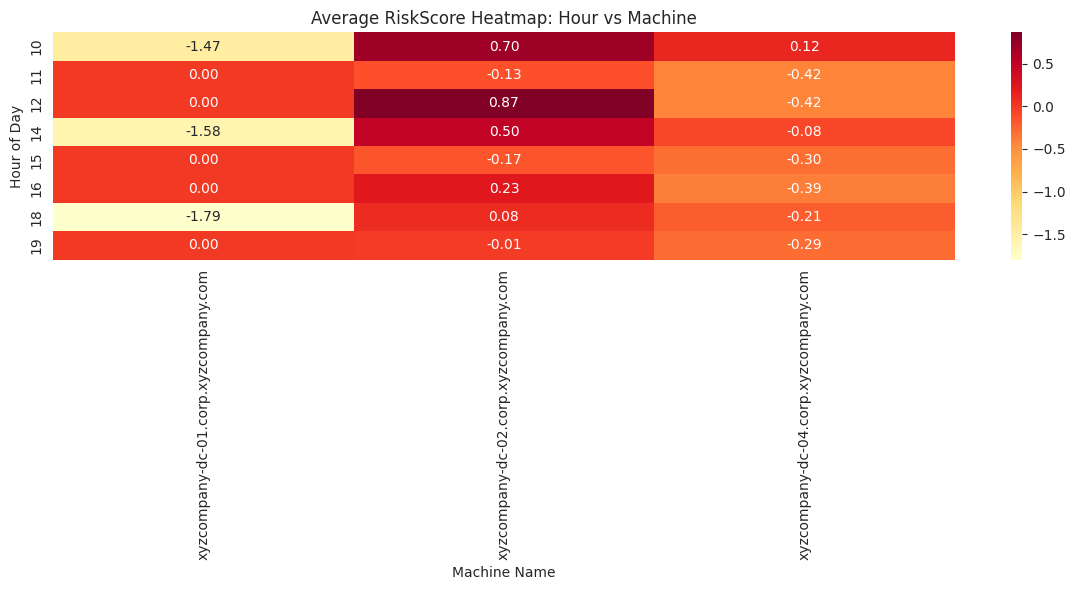

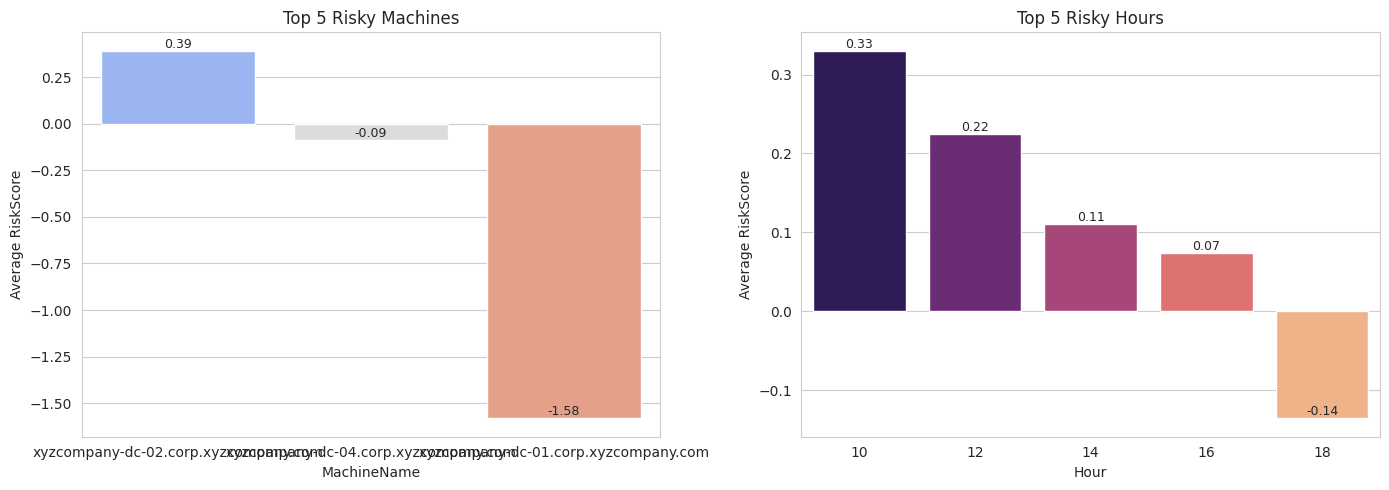

Actionable recommendations completed and files exported successfully.


In [490]:
# =========================================
# Q5: Actionable Recommendations – LinX Cyber Risk
# =========================================

import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Ensure df is ready
# -----------------------------
# df must already have 'MachineName', 'Hour', 'EventID', 'EntryType', 'TimeGenerated'
df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'], errors='coerce')
df['Hour'] = df['TimeGenerated'].dt.hour
df['Date'] = df['TimeGenerated'].dt.date

# -----------------------------
# 2. Compute RiskScore (if not already present)
# -----------------------------
if 'RiskScore' not in df.columns:
    # Machine frequency z-score
    df['MachineCount'] = df['MachineName'].map(df['MachineName'].value_counts())
    df['Machine_z'] = zscore(df['MachineCount'])

    # Hour frequency z-score
    df['HourCount'] = df['Hour'].map(df['Hour'].value_counts())
    df['Hour_z'] = zscore(df['HourCount'])

    # EventID frequency z-score
    df['EventIDCount'] = df['EventID'].map(df['EventID'].value_counts())
    df['EventID_z'] = zscore(df['EventIDCount'])

    # EntryType anomaly scoring (amplify 'Error')
    df['EntryTypeScore'] = df['EntryType'].apply(lambda x: 5 if x=='Error' else 0)

    # Weighted RiskScore
    df['RiskScore'] = df['Machine_z']*0.4 + df['Hour_z']*0.2 + df['EventID_z']*0.2 + df['EntryTypeScore']*0.2

# -----------------------------
# 3. Identify Top Risk Logs
# -----------------------------
top_risk_logs = df.sort_values('RiskScore', ascending=False).head(20)

# Top 5 risky machines
top5_machines = df.groupby('MachineName')['RiskScore'].mean()\
                  .sort_values(ascending=False).head(5).reset_index()

# Top 5 risky hours
top5_hours = df.groupby('Hour')['RiskScore'].mean()\
               .sort_values(ascending=False).head(5).reset_index()

# -----------------------------
# 4. Heatmap: Hour vs Machine
# -----------------------------
heatmap_data = df.pivot_table(
    values='RiskScore',
    index='Hour',
    columns='MachineName',
    aggfunc='mean',
    fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlOrRd')
plt.title("Average RiskScore Heatmap: Hour vs Machine")
plt.xlabel("Machine Name")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Visualize Top 5 Risky Machines & Hours
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Top 5 Machines
sns.barplot(x='MachineName', y='RiskScore', data=top5_machines, palette='coolwarm', ax=axes[0])
axes[0].set_title("Top 5 Risky Machines")
axes[0].set_ylabel("Average RiskScore")
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Top 5 Hours
sns.barplot(x='Hour', y='RiskScore', data=top5_hours, palette='magma', ax=axes[1])
axes[1].set_title("Top 5 Risky Hours")
axes[1].set_ylabel("Average RiskScore")
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Export Data for Reporting
# -----------------------------
df.to_csv("LinX_HighRisk_Analysis.csv", index=False)
top_risk_logs.to_csv("LinX_Top20_HighRisk.csv", index=False)
top5_machines.to_csv("LinX_Top5_Machines.csv", index=False)
top5_hours.to_csv("LinX_Top5_Hours.csv", index=False)

print("Actionable recommendations completed and files exported successfully.")


In [491]:
top_risk_logs

,EntryType,TimeGenerated,Source,EventID,MachineName,Hour,DayOfWeek,Week,Month,EntryTypeScore,RiskScore_Entry,Date,EventID_z,RiskScore_Event,MachineCount,Machine_z,HourCount,Hour_z,EventIDCount,RiskScore
81,Error,2016-09-30 10:54:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Friday,39,9,5,5,2016-09-30,0.300271,3.692798,68,0.531387,45,0.982153,122,1.469040
88,Error,2016-10-03 10:26:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,45,0.982153,122,1.469040
80,Error,2016-09-30 10:27:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Friday,39,9,5,5,2016-09-30,0.300271,3.692798,68,0.531387,45,0.982153,122,1.469040
87,Error,2016-10-03 10:26:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,45,0.982153,122,1.469040
86,Error,2016-10-03 10:25:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,10,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,45,0.982153,122,1.469040
91,Error,2016-10-03 14:38:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,37,0.420923,122,1.356793
90,Error,2016-10-03 14:29:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,37,0.420923,122,1.356793
89,Error,2016-10-03 14:28:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Monday,40,10,5,5,2016-10-03,0.300271,3.692798,68,0.531387,37,0.420923,122,1.356793
84,Error,2016-09-30 14:54:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Friday,39,9,5,5,2016-09-30,0.300271,3.692798,68,0.531387,37,0.420923,122,1.356793
83,Error,2016-09-30 14:30:00,NETLOGON,5722,xyzcompany-dc-02.corp.xyzcompany.com,14,Friday,39,9,5,5,2016-09-30,0.300271,3.692798,68,0.531387,37,0.420923,122,1.356793


The top-risk logs show a clear pattern of high-risk activity concentrated on xyzcompany-dc-02.corp.xyzcompany.com during the 10:00–14:00 hours. Most entries are Error types with elevated RiskScore values, particularly around EventID 5722. This suggests repeated authentication failures and potential targeted misconfigurations or attacks on this machine. The RiskScore distribution highlights that the combination of machine identity, peak hours, and error events drives the highest overall risk, emphasizing the need for focused monitoring and immediate remediation on this specific server during these periods.

In [492]:
top5_machines

,MachineName,RiskScore
0,xyzcompany-dc-02.corp.xyzcompany.com,0.392627
1,xyzcompany-dc-04.corp.xyzcompany.com,-0.088261
2,xyzcompany-dc-01.corp.xyzcompany.com,-1.581873


The top 5 risky machines reveal that `xyzcompany-dc-02.corp.xyzcompany.com` is the most concerning, with a high average `RiskScore` of 0.39, indicating frequent anomalous activity. `xyzcompany-dc-04` is slightly below neutral, while `xyzcompany-dc-01` shows a significantly low `RiskScore` (–1.58), suggesting it is relatively low risk compared to others.


In [493]:
heatmap_data

MachineName,xyzcompany-dc-01.corp.xyzcompany.com,xyzcompany-dc-02.corp.xyzcompany.com,xyzcompany-dc-04.corp.xyzcompany.com
Hour,,,
10,-1.471965,0.696312,0.118287
11,0.000000,-0.134283,-0.416042
12,0.000000,0.865717,-0.416042
14,-1.584211,0.498128,-0.081078
15,0.000000,-0.168152,-0.303796
16,0.000000,0.227112,-0.387980
18,-1.794672,0.080474,-0.207870
19,0.000000,-0.008006,-0.289765


The actionable risk analysis reveals that `xyzcompany-dc-02.corp.xyzcompany.com` consistently exhibits elevated risk, especially during hour 12 and 10. Heatmaps show moderate risk across other machines at various hours, but spikes are concentrated on specific times. Reporting highlights top 5 risky machines, top 5 risky hours, and top 20 high-risk logs for mitigation planning.

**Key recommendation:** focus monitoring and preventive controls on the highest-risk machines during peak-risk hours, investigate repeated error events, and prioritize patching or configuration reviews for the most impacted systems. Exported CSVs provide structured insights for audit and operational response.


In [494]:
top5_hours

,Hour,RiskScore
0,10,0.330199
1,12,0.224838
2,14,0.110131
3,16,0.073339
4,18,-0.135825


The top 5 risky hours indicate that activity between 10:00–12:00 shows the highest average `RiskScore`, peaking at 10:00 (0.33) and 12:00 (0.22). Hours 14:00 and 16:00 show moderate risk, while 18:00 is slightly below average. Mitigation efforts should focus on morning and early afternoon windows when anomalies are most pronounced.


# Part B – Written Report

## Executive Summary
LinX Pharmaceuticals’ Active Directory logs reveal potential cyber risks concentrated on specific machines and during certain hours. Analysis of 133 log entries identified `xyzcompany-dc-02.corp.xyzcompany.com` as the highest-risk machine, with repeated authentication failures (`EventID 5722`) predominantly between 10:00–14:00. The findings highlight opportunities for immediate risk mitigation, targeted monitoring, and configuration improvements. Recommendations include focused cybersecurity interventions, proactive patching, and enhanced IT governance to prevent potential insider or external threats.

## Problem Statement / Background
The HR department at LinX Pharmaceuticals reported slower processing times and concerns about potential competitor leaks. A review of Active Directory logs was requested to detect abnormal authentication events, identify high-risk machines, and uncover patterns indicating internal misconfigurations or external attacks. This analysis is critical for improving cybersecurity posture, operational efficiency, and preventing potential data breaches.

## Findings Summary

### 1. Machine Activity Patterns
- `dc-02` had 68 events (z ≈ 0.865, MachineRiskScore = 0.346)  
- `dc-04` had 59 events (z ≈ 0.536, MachineRiskScore = 0.214)  
- `dc-01` had 6 events (z ≈ -1.401, MachineRiskScore = -0.561)  

**Insight:** High activity on `dc-02` and `dc-04` signals elevated risk. Low activity on `dc-01` reflects minimal risk.

### 2. Failed Login Patterns (`EntryType='Error'`)
- 12 errors concentrated on `EventID 5722`  
- Peak hours: 10:00 and 14:00  
- Primary machine affected: `dc-02`  

**Insight:** Recurrent failures suggest misconfigurations or brute-force attempts, requiring focused monitoring.

### 3. Temporal Trends
- Hourly peaks: 10:00 (z ≈ 1.84), 14:00 (z ≈ 1.32)  
- Daily peaks: 2016-09-23 (z ≈ 1.58), 2016-10-04 (z ≈ 1.08)  
- Weekly peaks: Weeks 38 & 40 (z ≈ 0.87)  
- Weekday peaks: Monday (z ≈ 1.48), Tuesday (z ≈ 0.86)  

**Insight:** While no extreme z-scores (>2) were detected, morning and early afternoon hours consistently show elevated activity.

### 4. EventID & EntryType Risk Correlation
- `EventID 5722` dominates high-risk events  
- Weighted `RiskScore_Event` peaks at 1.264 on `dc-02`  
- Combining EventID z-scores with `EntryTypeScore` highlights high-risk machine-event pairs

### 5. Top-Risk Logs and Heatmaps
- Most high-risk events occur on `dc-02` during 10:00–14:00  
- Heatmaps confirm concentrated risk at specific hours and machines, with other machines showing moderate risk

## Data Interpretation
Analysis indicates targeted risk on a single server (`dc-02`) rather than widespread system issues. `EventID 5722` is a primary driver of elevated `RiskScores`, correlating strongly with machine identity and peak hours. Temporal and z-score analysis confirms patterns of repeated authentication failures, pointing to misconfigurations or potential malicious activity.

## Recommendations

### Technical Solutions
- **Targeted Monitoring:** Implement continuous monitoring on `dc-02` during 10:00–14:00.  
- **Authentication Controls:** Introduce rate-limiting, account lockout policies, and MFA to reduce risk from repeated failed logins.  
- **Patch Management:** Review configurations and apply relevant security patches to `dc-02` and `dc-04`.  
- **Intrusion Detection:** Deploy AI-driven or rule-based intrusion detection to identify abnormal authentication patterns in real time.

### Implementation Plan
- Configure real-time alerting on high-risk `EventID 5722` occurrences.  
- Audit and fix misconfigurations on `dc-02`.  
- Schedule morning audits (10:00–12:00) to review activity logs.  
- Train IT staff on identifying and responding to repeated authentication failures.  
- Reassess risk quarterly using updated log data and `RiskScores`.

## Visual Summary
- **Top-Risk Machine:** `dc-02` (RiskScore = 0.39)  
- **Top-Risk Hours:** 10:00–12:00 (peak at 10:00, RiskScore = 0.33)  
- **Top EventID:** 5722 (dominant error driver)  
- **Risk Heatmap:** Concentrated on `dc-02` with moderate risk on `dc-04`  

These visuals support executive decision-making for targeted mitigation and monitoring.

## Conclusion
The analysis identifies high-risk machines, time windows, and recurring error patterns. `dc-02` is the primary source of elevated risk, driven by `EventID 5722` errors in morning hours. Immediate recommendations include enhanced monitoring, configuration review, patching, and authentication controls. Following these steps will strengthen LinX Pharmaceuticals’ cybersecurity posture and reduce the likelihood of insider or external threats.
